# Federated normative modeling

In multi-site neuroimaging studies, data often cannot leave the hospital or institution where it was collected, due to privacy regulations such as GDPR. **Federated learning (FL)** addresses this constraint: each site trains a model locally and shares only the trained model parameters; never the raw data.

This tutorial demonstrates a FL workflow for normative modeling using the PCNtoolkit. For more details you can read the paper below:

> Kia SM, Huijsdens H, Rutherford S, de Boer A, Dinga R, Wolfers T, et al. (2022)  
> *Closing the life-cycle of normative modeling using federated hierarchical Bayesian regression.*  
> PLoS ONE 17(12): e0278776. https://doi.org/10.1371/journal.pone.0278776

## What we will do

**Classic normative modelling workflow**

1. *Fit a model* on all data together (let's call it *baseline model* as later we will compare it with the aggregated model produced from the FL workflow)

**Prepare the data for FL**

2. *Split* the data into a large central dataset and two smaller ones
3. *Fit a central model* on the central dataset only

**FL with `extend()`**

4. *Extend* the central model to each of the two smaller datasets
5. *Merge (= aggregate)* the central model and the two extended models into a single global model
6. *Evaluate* the final aggregated model 

**FL with `transfer()`**

7. *Transfer* the central model to each of the two smaller datasets
7. *Merge* the central model and the two transferred models into a single global model
6. *Evaluate* the final aggregated model 

**Evaluation**

10. *Compare* the aggregated models to the baseline model

## The functions that we will use

| Function | Role |
|---|---|
| `NormativeModel.fit()` | Fit the central model |
| `NormativeModel.extend()` | Refit the central model with data from the smaller model + synthetic data (generated from the central model) |
| `NormativeModel.transfer()` | Transfer the central model's priors to the smaller dataset |
| `NormativeModel.merge()` | Merge (= aggregate) central + extended/transferred models |
| `NormativeModel.predict()` | Evaluate the final aggregated model |


## Imports


In [22]:
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import pcntoolkit.util.output
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormalLikelihood,
    NormativeModel,
    NormData,
    load_fcon1000,
    make_prior,
    plot_centiles_advanced,
    plot_qq,
)

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")
pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(
    action="ignore", category=FutureWarning
)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(
    False
)

## Load data

We use the [fcon1000](https://fcon_1000.projects.nitrc.org/fcpClassic/FcpTable.html) dataset that is included in PCNtoolkit, which contains resting state fMRI from 1078 subjects across 23 sites. We select a single response variable (`WM-hypointensities`) to keep the tutorial fast.


In [23]:
# Download the dataset
norm_data: NormData = load_fcon1000()

# Select only the white matter hypointensities feature
features_to_model = ["WM-hypointensities"]
norm_data = norm_data.sel(
    {"response_vars": features_to_model}
)

# Show all available sites
all_sites = np.unique(
    norm_data.batch_effects.sel(
        batch_effect_dims="site"
    ).values
)
print(
    f"Total sites: {len(all_sites)}"
)
print(f"Sites: {all_sites}")

Total sites: 23
Sites: ['AnnArbor_a' 'AnnArbor_b' 'Atlanta' 'Baltimore' 'Bangor' 'Beijing_Zang'
 'Berlin_Margulies' 'Cambridge_Buckner' 'Cleveland' 'ICBM' 'Leiden_2180'
 'Leiden_2200' 'Milwaukee_b' 'Munchen' 'NewYork_a' 'NewYork_a_ADHD'
 'Newark' 'Oulu' 'Oxford' 'PaloAlto' 'Pittsburgh' 'Queensland'
 'SaintLouis']


## Split data

We split the data into:

- A large central dataset (19 sites)
- Two smaller datasets (each dataset has 2 sites) 

In a FL scenario the large model would be owned by a central location (e.g., a hospital in the Netherlands) and the smaller ones by remote locations 1 and 2 (e.g, a hospital in France and in the USA). All these locations don't want to share their data due to privacy. For this reason, they use the FL workflow.


In [24]:
# Pick 2 sites for each remote location
location1_sites = list(all_sites[:2])
location2_sites = list(all_sites[2:4])
print(
    f"Location 1 sites: {location1_sites}"
)
print(
    f"Location 2 sites: {location2_sites}"
)

# Split off location 1
location1_data, remaining = (
    norm_data.batch_effects_split(
        {"site": location1_sites},
        names=("location1", "remaining"),
    )
)

# Split off location 2 
location2_data, central_data = (
    remaining.batch_effects_split(
        {"site": location2_sites},
        names=("location2", "central"),
    )
)

# Create train/test splits for each location
train_central, test_central = (
    central_data.train_test_split()
)
train_location1, test_location1 = (
    location1_data.train_test_split()
)
train_location2, test_location2 = (
    location2_data.train_test_split()
)

# Global train/test for the baseline model
train_all, test_all = (
    norm_data.train_test_split()
)

print(
    f"\nCentral: "
    f"{train_central.X.shape[0]} train, "
    f"{test_central.X.shape[0]} test"
)
print(
    f"Location 1: "
    f"{train_location1.X.shape[0]} train, "
    f"{test_location1.X.shape[0]} test"
)
print(
    f"Location 2: "
    f"{train_location2.X.shape[0]} train, "
    f"{test_location2.X.shape[0]} test"
)
print(
    f"All data: "
    f"{train_all.X.shape[0]} train, "
    f"{test_all.X.shape[0]} test"
)

Location 1 sites: [np.str_('AnnArbor_a'), np.str_('AnnArbor_b')]
Location 2 sites: [np.str_('Atlanta'), np.str_('Baltimore')]

Central: 776 train, 195 test
Location 1: 44 train, 12 test
Location 2: 40 train, 11 test
All data: 862 train, 216 test


## Visualize the data


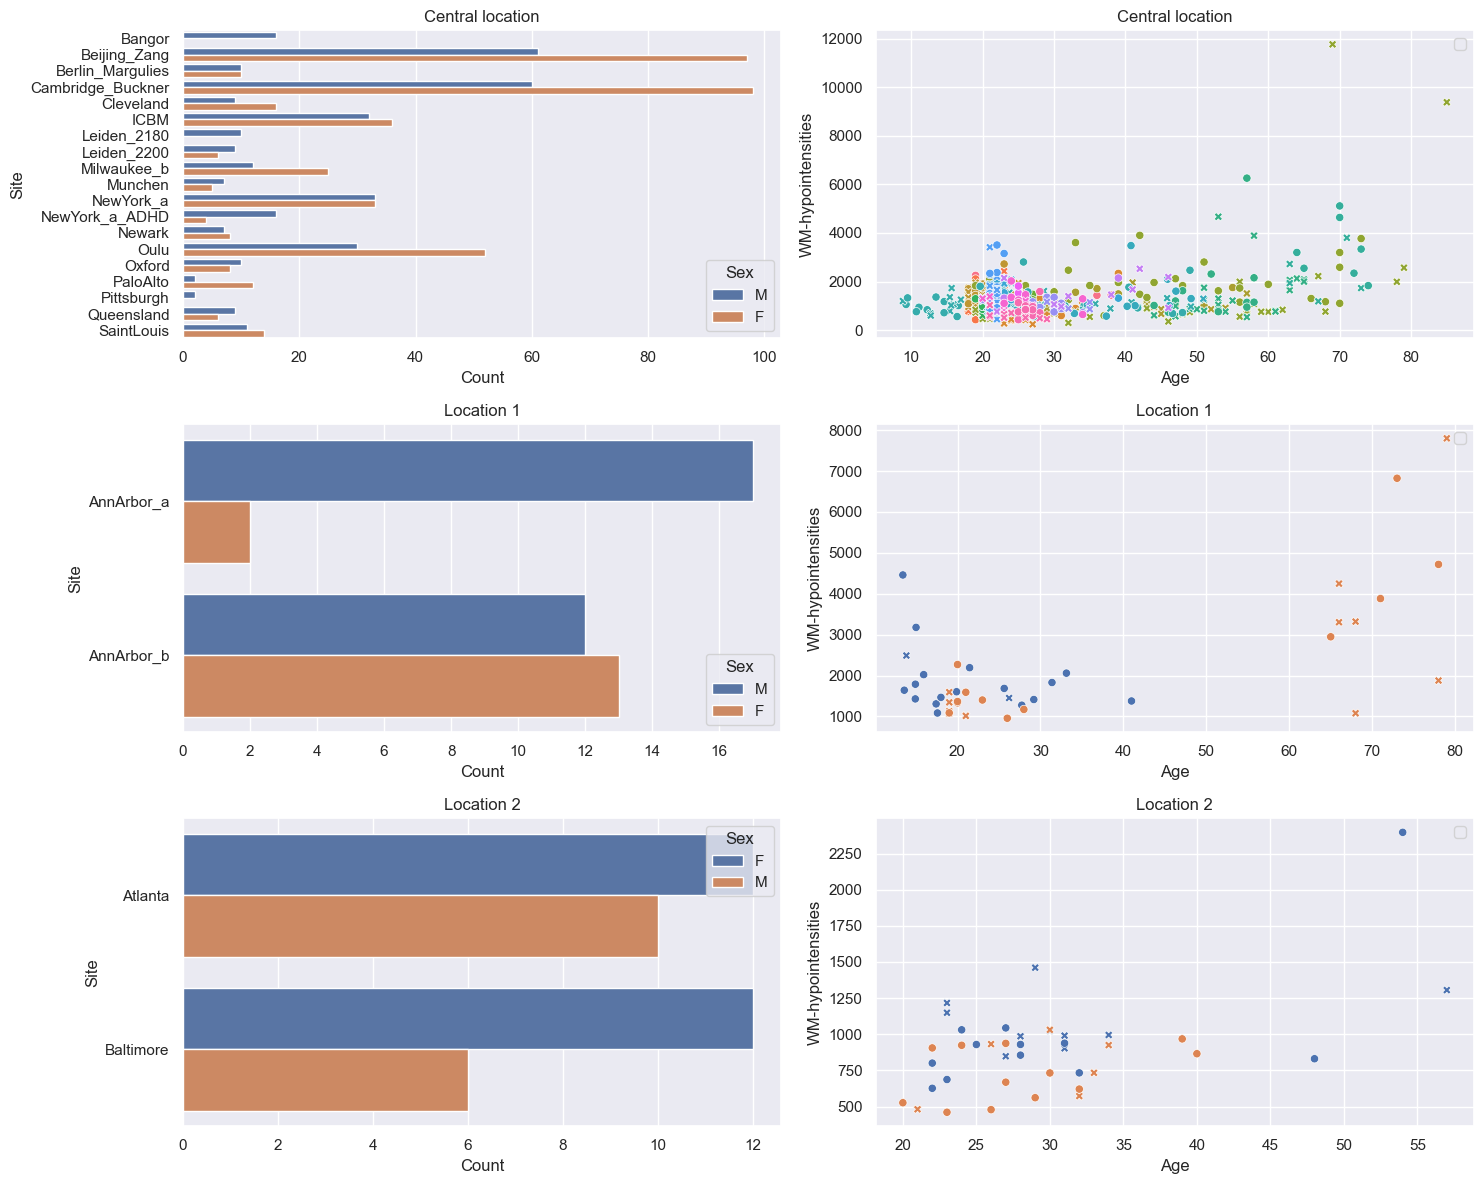

In [25]:
feature = features_to_model[0]
datasets = {
    "Central location": train_central,
    "Location 1": train_location1,
    "Location 2": train_location2,
}

fig, axes = plt.subplots(
    3, 2, figsize=(15, 12)
)

# for every dataset
for i, (name, data) in enumerate(
    datasets.items()
):
    df = data.to_dataframe()
    # Count plot
    sns.countplot(
        data=df,
        y=("batch_effects", "site"),
        hue=("batch_effects", "sex"),
        ax=axes[i, 0],
        orient="h",
    )
    axes[i, 0].legend(title="Sex")
    axes[i, 0].set_title(
        f"{name}"
    )
    axes[i, 0].set_xlabel("Count")
    axes[i, 0].set_ylabel("Site")

    # Scatter plot
    sns.scatterplot(
        data=df,
        x=("X", "age"),
        y=("Y", feature),
        hue=("batch_effects", "site"),
        style=("batch_effects", "sex"),
        ax=axes[i, 1],
    )
    axes[i, 1].legend([], [])
    axes[i, 1].set_title(
        f"{name}"
    )
    axes[i, 1].set_xlabel("Age")
    axes[i, 1].set_ylabel(feature)

plt.tight_layout()
plt.show()

## Configure the HBR model

We define a shared model configuration that will be used for **all** models (baseline, central, transferred, and aggregated). This ensures a fair comparison. We use a Normal likelihood HBR with B-spline basis functions.


In [26]:
mu = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        sigma=make_prior(dist_name="Normal", dist_params=(0.0, 1.0), mapping="softplus", mapping_params=(0.0, 3.0)),
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

likelihood = NormalLikelihood(mu, sigma)

template_hbr = HBR(
    name="template",
    cores=16,
    progressbar=False,
    draws=1500,
    tune=500,
    chains=4,
    nuts_sampler="nutpie",
    likelihood=likelihood,
)


---

## Part 1: Baseline model

In a non-FL scenario, we would pool all the data from all the 23 sites into a single dataset and train one model.


In [ ]:
baseline_model = NormativeModel(
    template_regression_model=template_hbr,
    savemodel=True,
    evaluate_model=True,
    saveresults=True,
    saveplots=False,
    save_dir=(
        "resources/federated/baseline"
    ),
    inscaler="standardize",
    outscaler="standardize",
);

# Use the data from all 23 sites, before any splitting happened.
baseline_model.fit_predict(
    train_all, test_all);

## Part 2: FL with `extend()`

Now we simulate the FL scenario. The central location **does not have access** to the data at Location 1 and Location 2. Only model parameters are exchanged.

### Step 1: Train the central model

The central location trains an HBR model using only its own 19 sites.


In [40]:
central_model = NormativeModel(
    template_regression_model=template_hbr,
    savemodel=True,
    evaluate_model=True,
    saveresults=False,
    saveplots=False,
    save_dir=(
        "resources/federated/central"
    ),
    inscaler="standardize",
    outscaler="standardize",
)

central_model.fit(train_central)

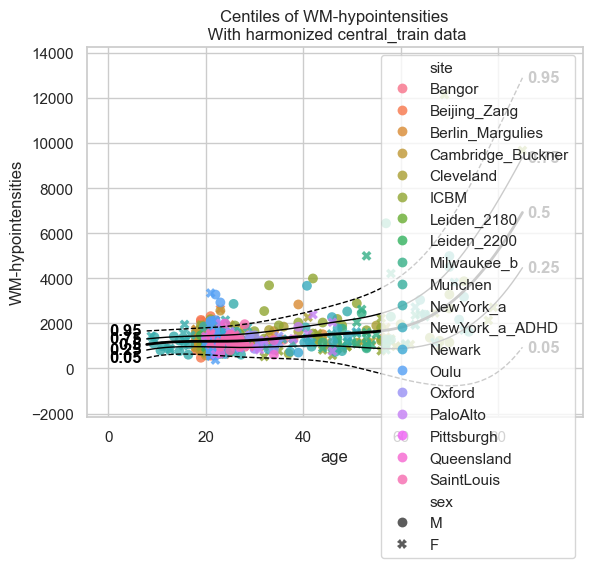

In [29]:
# Centile curves for the central model
plot_centiles_advanced(
    central_model,
    scatter_data=train_central,
    batch_effects="all",
)

### Step 2: Extend the central model to remote locations

Each remote location receives the central model json files that are saved in `resources/federated/central` and calls `extend()` locally using its own private data.

`extend()` synthesizes data from the central model's learned distribution, merges it with the real local data, and refits a full model.

No real data is exchanged only model parameters.


In [ ]:
# Location 1 loads the central model from disk
central_model = NormativeModel.load("resources/federated/central")

# Location 1 extends the central model
# with their private data.
extended_1 = central_model.extend(
    train_location1,
    save_dir=(
        "resources/federated/extended_1"
    ),
)

In [42]:
# Location 2 loads the central model from disk
central_model = NormativeModel.load("resources/federated/central")

# Location 2 extends the central model
# with their private data.
extended_2 = central_model.extend(
    train_location2,
    save_dir=(
        "resources/federated/extended_2"
    ),
)

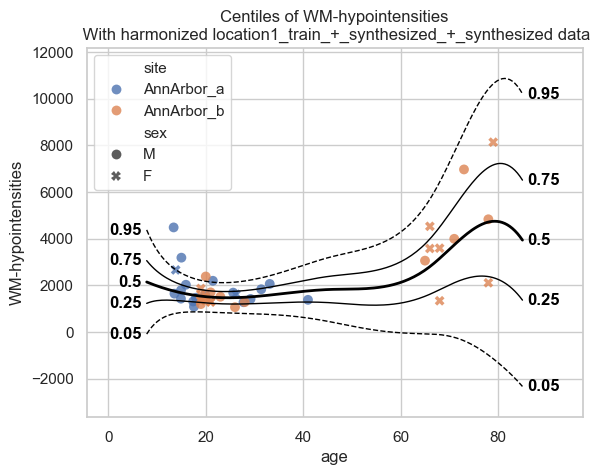

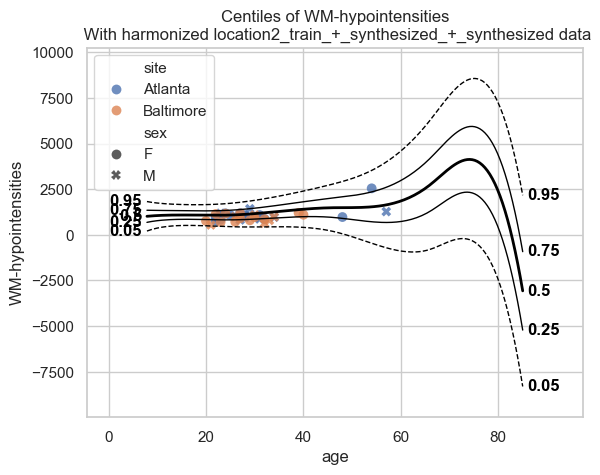

In [43]:
# Visualize the extended models
plot_centiles_advanced(
    extended_1,
    scatter_data=train_location1,
    batch_effects="all",
)

plot_centiles_advanced(
    extended_2,
    scatter_data=train_location2,
    batch_effects="all",
)

Each extended model knows about both the central sites (via synthetic data) and its own local sites.

### Step 3: Merge extended models

The remote locations send back to the central location their updated model parameters. The central location merges the central model with both extended models using `NormativeModel.merge()`.

Under the hood, `merge()` does the following:

1. Calls `synthesize()` on each model to generate synthetic data from its learned distribution
2. Pools all synthetic datasets together
3. Refits a single global model on the combined synthetic data

No real data is exchanged only model parameters.


In [ ]:
# For simplicity, we will not load the extended models from disk 
# using `NormativeModel.load`, but in practice you would do that here.

# Merge central + both extended models
aggregated_model_with_extend = NormativeModel.merge(
    save_dir=(
        "resources/federated/merged_extend"
    ),
    models=[
        central_model,
        extended_1,
        extended_2,
    ],
)

### Step 4: Predict with the aggregated model

The aggregated model now covers all 23 sites. We can predict on the full test set.


In [ ]:
# make a copy that holds all the test data
test_all_extended = test_all.copy(deep=True)

# Predict the test data based on the aggegated model
aggregated_model_with_extend.predict(
    test_all_extended
);

## Part 3: FL with `transfer()`

We now repeat the FL workflow, but using `transfer()` instead of `extend()`.

### Step 1: Transfer to both locations


In [35]:
# Location 1 transfers the central model
transferred_1 = central_model.transfer(
    train_location1,
    save_dir=(
        "resources/federated/transferred_1"
    ),
)

# Location 2 transfers the central model
transferred_2 = central_model.transfer(
    train_location2,
    save_dir=(
        "resources/federated/transferred_2"
    ),
)

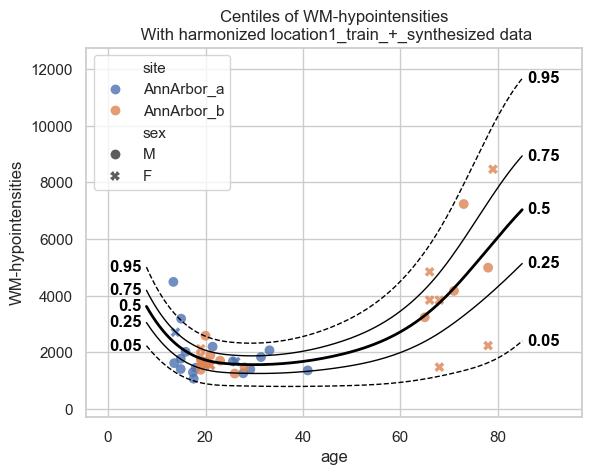

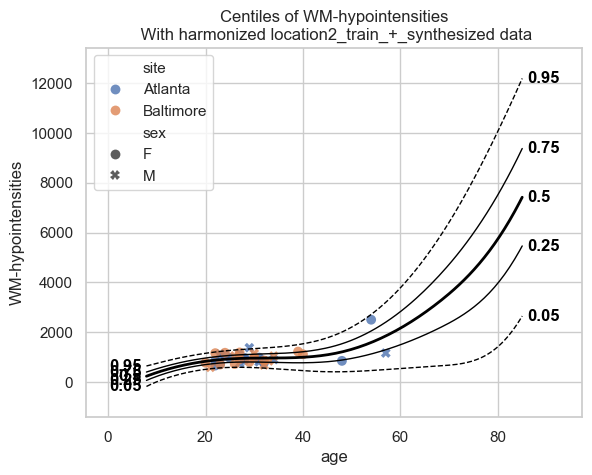

In [36]:
# Visualize the transferred models
plot_centiles_advanced(
    transferred_1,
    scatter_data=train_location1,
    batch_effects="all",
)

plot_centiles_advanced(
    transferred_2,
    scatter_data=train_location2,
    batch_effects="all",
)

### Step 2: Merge transferred models and predict


In [37]:
# Merge central + both transferred models
aggregated_model_with_transfer = NormativeModel.merge(
    save_dir="resources/federated/merged_transfer",
    models=[
        central_model,
        transferred_1,
        transferred_2,
    ],
)

# Predict on the full test set
test_all_transferred = test_all.copy(deep=True)
aggregated_model_with_transfer.predict(test_all_transferred);

---

## Aggregated vs baseline model

We now compare all three models:

- **baseline**: all data pooled 
- **Aggregated (extend)**: remote sites used `extend()` 
- **Aggregated (transfer)**: remote sites used `transfer()` 

### Centile curves


=== baseline model ===


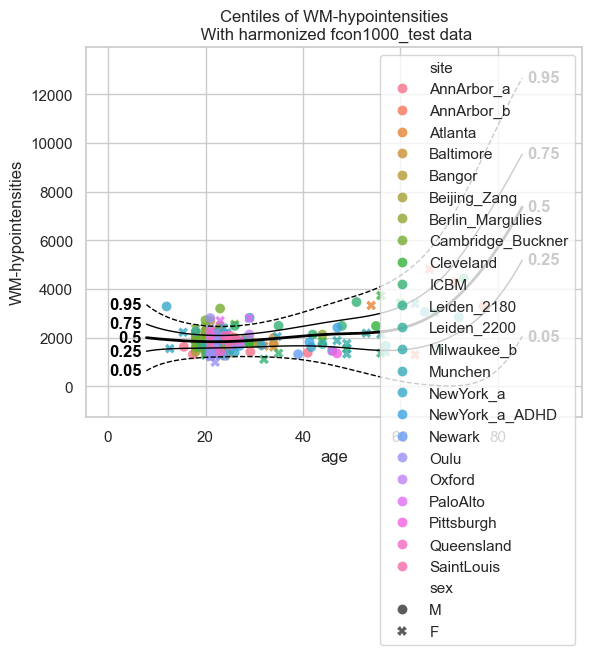


=== Aggregated (extend) ===


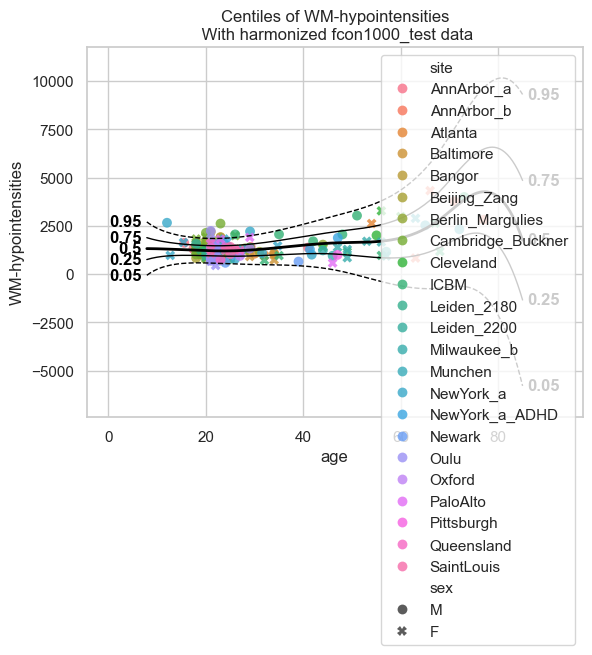


=== Aggregated (transfer) ===


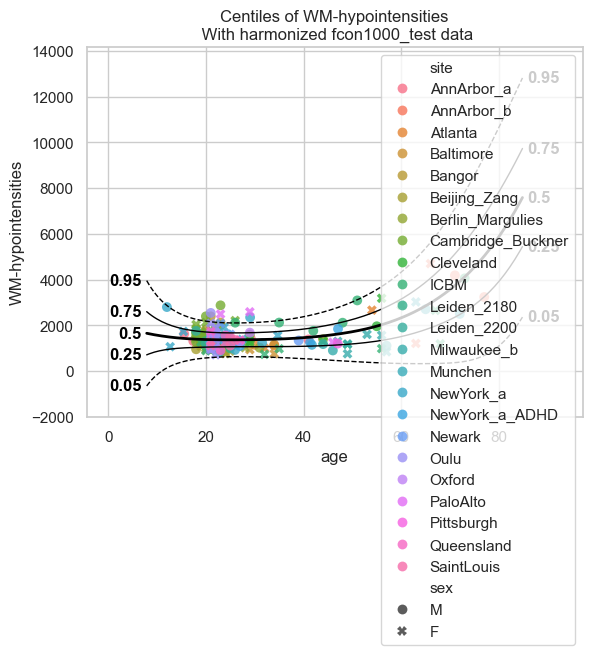

In [38]:
# baseline model centiles
print("=== baseline model ===")
plot_centiles_advanced(
    baseline_model,
    scatter_data=test_all,
    batch_effects="all",
)

# Aggregated model centiles (extend)
print("\n=== Aggregated (extend) ===")
plot_centiles_advanced(
    aggregated_model_with_extend,
    scatter_data=test_all,
    batch_effects="all",
)

# Aggregated model centiles (transfer)
print("\n=== Aggregated (transfer) ===")
plot_centiles_advanced(
    aggregated_model_with_transfer,
    scatter_data=test_all,
    batch_effects="all",
)

### QQ plots and evaluation metrics


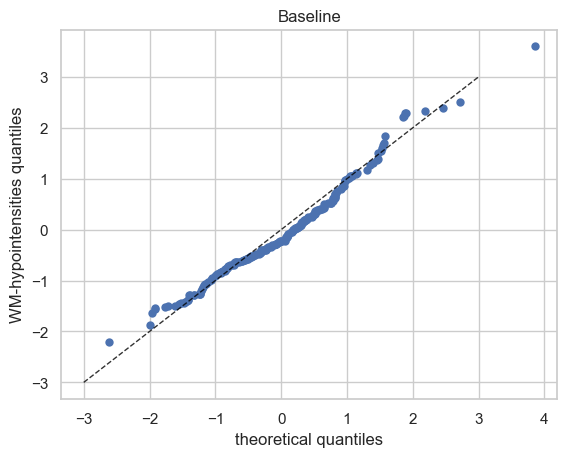

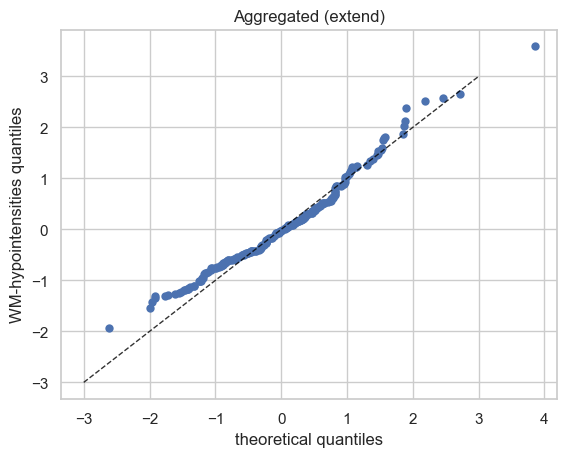

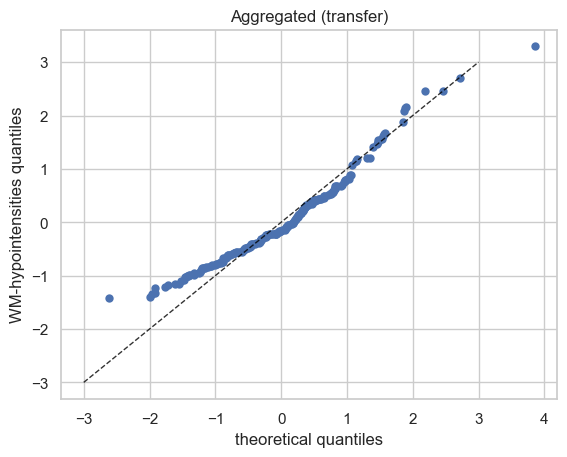

,statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
,response_vars,,,,,,,,,,,
baseline,WM-hypointensities,0.360218,0.037037,0.341988,-0.320961,0.798308,0.357200,485.243446,0.490306,1.828886e-14,0.642800,0.967453
Aggregated (extend),WM-hypointensities,0.369571,0.038889,0.322612,-0.330280,0.854522,0.369446,480.599146,0.495714,8.515981e-15,0.630554,0.961769
Aggregated (transfer),WM-hypointensities,0.307336,0.049630,0.354095,-0.273420,0.911382,0.307070,503.809550,0.405179,6.102418e-10,0.692930,0.946122


In [39]:
# QQ plots for all three models
plt.title("Baseline")
plot_qq(test_all, plot_id_line=True)

plt.title("Aggregated (extend)")
plot_qq(
    test_all_extended, plot_id_line=True
)

plt.title("Aggregated (transfer)")
plot_qq(
    test_all_transferred, plot_id_line=True
)

# Evaluation metrics for all three
baseline_stats = (
    test_all.get_statistics_df()
)
extend_stats = (
    test_all_extended.get_statistics_df()
)
transfer_stats = (
    test_all_transferred.get_statistics_df()
)

comparison = pd.concat(
    [
        baseline_stats,
        extend_stats,
        transfer_stats,
    ]
    , keys=[
        "baseline",
        "Aggregated (extend)",
        "Aggregated (transfer)",
    ]
)
comparison

## Conclusions

All the models perform very similarly. So the FL workflow, where the data are different locations. performs as good as
the baseline workflow, where all the data are in one location.

In more detail:

### Centile plots

Looking at the centile plots, both aggregated models fit the test
data well across most of the age range. 

The **aggregated (extend)** model shows an abrupt divergence at
old ages (> 70 years). This happens because `extend()` fits a model on synthetic 
data from the central model and real local data. The synthetic and the real local 
data have almost no datapoints beyond age ~70 . 
As a result the model does not fit well for these ages.


### QQ plots

Both aggregated models show a systematic deviation from the
identity line at the **lower tail** of the QQ plot. That means the
model "expects" the lowest-percentile subjects to have smaller
observed values than they actually do.

### Evaluation metrics

Looking at all evaluation metrics, the **aggregated (transfer)** performs worse 
than the other two models. While the **aggregated (extend)** performs
*slightly* worse than the baseline model.
